In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
results_df = pd.read_csv("football_results/results_v003.csv",encoding="utf-8")
goal_scorers_df = pd.read_csv("football_results/goalscorers.csv",encoding="utf-8")
shotout_df = pd.read_csv("football_results/shootouts.csv",encoding="utf-8")

In [3]:
results_df.shape

(49501, 9)

In [4]:
results_df.head(5)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [5]:
results_df.isna().sum()

date          0
home_team     0
away_team     0
home_score    6
away_score    6
tournament    0
city          0
country       0
neutral       0
dtype: int64

In [6]:
results_df.shape

(49501, 9)

In [7]:
results_df["tournament"].value_counts()

tournament
Friendly                                18388
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                           1060
                                        ...  
Copa Confraternidad                         1
Benedikt Fontana Cup                        1
ConIFA Challenger Cup                       1
CONIFA World Cup qualification              1
South Asian Super Cup                       1
Name: count, Length: 200, dtype: int64

In [8]:
results_df["neutral"].value_counts()

neutral
False    36360
True     13141
Name: count, dtype: int64

In [9]:
results_df.columns

Index(['date', 'home_team', 'away_team', 'home_score', 'away_score',
       'tournament', 'city', 'country', 'neutral'],
      dtype='str')

In [10]:
results_df = results_df.sort_values("date",ascending=True)
test_df = results_df.head(20)

In [11]:
unique_home_t = list(results_df["home_team"].unique())
unique_away_t = list(results_df["away_team"].unique())
all_t = unique_home_t + unique_away_t
all_t = np.array(all_t)
all_t = np.unique(all_t)

In [12]:
all_t

array(['Abkhazia', 'Afghanistan', 'Albania', 'Alderney', 'Algeria',
       'Ambazonia', 'American Samoa', 'Andalusia', 'Andorra', 'Angola',
       'Anguilla', 'Antigua and Barbuda', 'Arameans Suryoye', 'Argentina',
       'Armenia', 'Artsakh', 'Aruba', 'Asturias', 'Australia', 'Austria',
       'Aymara', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh',
       'Barawa', 'Barbados', 'Basque Country', 'Belarus', 'Belgium',
       'Belize', 'Benin', 'Bermuda', 'Bhutan', 'Biafra', 'Bolivia',
       'Bonaire', 'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'British Virgin Islands', 'Brittany', 'Brunei', 'Bulgaria',
       'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Canada',
       'Canary Islands', 'Cape Verde', 'Cascadia', 'Catalonia',
       'Cayman Islands', 'Central African Republic', 'Central Spain',
       'Chad', 'Chagos Islands', 'Chameria', 'Chechnya', 'Chile', 'China',
       'Cilento', 'Colombia', 'Comoros', 'Congo', 'Cook Islands',
       'Corsica', 'Costa Rica',

In [13]:
K_FACTORS = {
    "Friendly": 10,
    "British Home Championship": 25,
    "Évence Coppée Trophy": 10,
    "Muratti Vase": 10,
    "Copa Lipton": 15,
    "Copa Newton": 15,
    "Copa Premio Honor Argentino": 15,
    "Olympic Games": 25,
    "Copa Premio Honor Uruguayo": 15,
    "Far Eastern Championship Games": 15,
    "Copa Roca": 15,
    "Copa América": 50,
    "Inter-Allied Games": 10,
    "Peace Cup": 10,
    "Open International Championship": 10,
    "Soccer Ashes": 10,
    "Copa Chevallier Boutell": 15,
    "Nordic Championship": 20,
    "Central European International Cup": 30,
    "Baltic Cup": 20,
    "Balkan Cup": 20,
    "Central American and Caribbean Games": 15,
    "FIFA World Cup": 60,
    "Copa Rio Branco": 15,
    "FIFA World Cup qualification": 40,
    "Bolivarian Games": 15,
    "CCCF Championship": 25,
    "NAFC Championship": 25,
    "Copa Oswaldo Cruz": 15,
    "Asian Games": 20,
    "Pan American Championship": 20,
    "Copa del Pacífico": 15,
    "Copa Bernardo O'Higgins": 15,
    "AFC Asian Cup qualification": 35,
    "Atlantic Cup": 15,
    "AFC Asian Cup": 50,
    "African Cup of Nations": 50,
    "Copa Paz del Chaco": 15,
    "Merdeka Tournament": 15,
    "UEFA Euro qualification": 40,
    "Southeast Asian Peninsular Games": 15,
    "African Friendship Games": 10,
    "UEFA Euro": 50,
    "Windward Islands Tournament": 10,
    "African Cup of Nations qualification": 35,
    "Vietnam Independence Cup": 10,
    "Copa Carlos Dittborn": 15,
    "Phillip Seaga Cup": 10,
    "CONCACAF Championship": 45,
    "Copa Juan Pinto Durán": 15,
    "Arab Cup": 25,
    "South Pacific Games": 15,
    "Zambian Independence Tournament": 10,
    "CONCACAF Championship qualification": 30,
    "Copa Artigas": 15,
    "All-African Games": 20,
    "GaNEFo": 10,
    "Copa América qualification": 35,
    "King's Cup": 15,
    "Gulf Cup": 25,
    "Indonesia Tournament": 10,
    "Korea Cup": 15,
    "Palestine Cup": 10,
    "Brazil Independence Cup": 15,
    "Copa Ramón Castilla": 15,
    "Oceania Nations Cup": 40,
    "CECAFA Cup": 20,
    "Kuneitra Cup": 10,
    "Copa Félix Bogado": 10,
    "Real Madrid 75th Anniversary Cup": 10,
    "Beijing International Friendship Tournament": 10,
    "Southeast Asian Games": 15,
    "Kirin Cup": 15,
    "CFU Caribbean Cup qualification": 20,
    "CFU Caribbean Cup": 25,
    "Amílcar Cabral Cup": 15,
    "FIFA 75th Anniversary Cup": 10,
    "Indian Ocean Island Games": 10,
    "Guangzhou International Friendship Tournament": 10,
    "Mundialito": 20,
    "South Pacific Mini Games": 10,
    "West African Cup": 15,
    "Nehru Cup": 15,
    "Merlion Cup": 10,
    "Trans-Tasman Cup": 15,
    "Great Wall Cup": 10,
    "South Asian Games": 15,
    "UDEAC Cup": 15,
    "Rous Cup": 15,
    "CONMEBOL–UEFA Cup of Champions": 30,
    "Miami Cup": 10,
    "Lunar New Year Cup": 10,
    "Arab Cup qualification": 20,
    "Tournoi de France": 15,
    "Malta International Tournament": 10,
    "Four Nations Tournament": 10,
    "Matthews Cup": 10,
    "Tournament Burkina Faso": 10,
    "Marlboro Cup": 10,
    "Melanesia Cup": 15,
    "Island Games": 10,
    "NAFU Championship": 15,
    "Dynasty Cup": 15,
    "Dakar Tournament": 10,
    "UNCAF Cup": 25,
    "Scania 100 Tournament": 10,
    "Gold Cup": 45,
    "USA Cup": 10,
    "Jordan International Tournament": 10,
    "Confederations Cup": 40,
    "East Asian Games": 15,
    "United Arab Emirates Friendship Tournament": 10,
    "Joe Robbie Cup": 10,
    "Oceania Nations Cup qualification": 25,
    "Simba Tournament": 10,
    "SAFF Cup": 20,
    "AFF Championship": 25,
    "King Hassan II Tournament": 10,
    "Cyprus International Tournament": 10,
    "Dunhill Cup": 10,
    "COSAFA Cup qualification": 15,
    "COSAFA Cup": 20,
    "Gold Cup qualification": 30,
    "AFF Championship qualification": 20,
    "SKN Football Festival": 10,
    "Four Nations' Cup": 10,
    "UNIFFAC Cup": 15,
    "WAFF Championship": 20,
    "Millennium Cup": 10,
    "Cup of Ancient Civilizations": 10,
    "Prime Minister's Cup": 10,
    "Unity Cup": 10,
    "The Other Final": 10,
    "EAFF Championship": 25,
    "TIFOCO Tournament": 10,
    "Afro-Asian Games": 10,
    "AFC Challenge Cup": 20,
    "FIFI Wild Cup": 10,
    "ELF Cup": 10,
    "Viva World Cup": 10,
    "AFC Challenge Cup qualification": 15,
    "Coupe de l'Outre-Mer": 10,
    "VFF Cup": 10,
    "Corsica Cup": 10,
    "Dragon Cup": 10,
    "ABCS Tournament": 10,
    "Nile Basin Tournament": 10,
    "Nations Cup": 15,
    "Copa Confraternidad": 10,
    "Pacific Games": 15,
    "Superclásico de las Américas": 15,
    "Palestine International Championship": 10,
    "Philippine Peace Cup": 10,
    "Kirin Challenge Cup": 10,
    "International Tournament of Peoples, Cultures and Tribes": 10,
    "Tynwald Hill Tournament": 10,
    "OSN Cup": 10,
    "CONIFA World Football Cup": 10,
    "Niamh Challenge Cup": 10,
    "CONIFA European Football Cup": 10,
    "Benedikt Fontana Cup": 10,
    "ConIFA Challenger Cup": 10,
    "Hungary Heritage Cup": 10,
    "World Unity Cup": 10,
    "AFC Solidarity Cup": 15,
    "Pacific Mini Games": 10,
    "Intercontinental Cup": 15,
    "UEFA Nations League": 40,
    "CONCACAF Nations League qualification": 25,
    "Atlantic Heritage Cup": 10,
    "Inter Games": 10,
    "CONCACAF Nations League": 35,
    "CONIFA World Cup qualification": 10,
    "Three Nations Cup": 10,
    "Mahinda Rajapaksa Cup": 10,
    "Navruz Cup": 10,
    "CONIFA Africa Football Cup": 10,
    "CONIFA South America Football Cup": 10,
    "MSG Prime Minister's Cup": 10,
    "Tri Nation Tournament": 10,
    "CAFA Nations Cup": 20,
    "Mauritius Four Nations Cup": 10,
    "CONIFA World Football Cup qualification": 10,
    "CONIFA Asia Cup": 10,
    "FIFA Series": 10,
    "Marianas Cup": 10,
    "Tri-Nations Series": 10,
    "ASEAN Championship qualification": 20,
    "ASEAN Championship": 25,
    "EAFF Championship qualification": 15,
    "Mapinduzi Cup": 10,
    "Canadian Shield": 10,
    "Outrigger Challenge Cup": 10,
    "South Asian Super Cup": 10,
    "CONCACAF Series": 15,
    "Al Ain International Cup": 10,
    "Morocco, Capital of African Football": 10,
    "Mukuru 4 Nations": 10,
    "Diamond Jubilee International Football Tournament": 10,
    "Tri-Nations Cup": 10,
}

In [14]:
def get_k(tournament):
    return K_FACTORS.get(tournament, 10)

In [15]:
starting_elo = 1500
home_elos = []
away_elos = []
elos = {}
for t in all_t:
    elos[str(t)] = starting_elo
elos

for i in range(results_df.shape[0]):
    row = results_df.loc[i,:]
    
    tournament = row["tournament"]
    neutral = row["neutral"]
    
    home_t = row["home_team"]
    home_elo = elos[home_t]
    home_elos.append(home_elo)
    home_score = row["home_score"]
    
    away_t = row["away_team"]
    away_score = row["away_score"]
    away_elo = elos[away_t]
    away_elos.append(away_elo)

    if neutral == False:
        home_elo_adj = home_elo + 100
    else:
        home_elo_adj = home_elo

    p1_beats_p2 = 1/ (1+10**((away_elo-home_elo_adj)/400))
    p2_beats_p1 = 1 - p1_beats_p2

    k_constant = get_k(tournament)
    
    if home_score > away_score:
        winner = "home"
        s_home = 1
        s_away = 0
        
    elif home_score == away_score:
        winner = "draw"
        s_home = 0.5
        s_away = 0.5
        
    else:
        winner = "away"
        s_home = 0
        s_away = 1 

    home_r = k_constant * ( s_home - p1_beats_p2)
    away_r = k_constant * ( s_away - p2_beats_p1)

    home_elo = home_elo + home_r
    away_elo = away_elo + away_r

    elos[home_t] = home_elo
    elos[away_t] = away_elo

results_df["home_elo"] = home_elos
results_df["away_elo"] = away_elos

In [16]:
d = {}
d["team"] = elos.keys()
d["elo"] = elos.values()
elos_df = pd.DataFrame(d)

In [17]:
elos_df.sort_values("elo",ascending=False)

,team,elo
277,Spain,2094.803810
102,France,2055.584932
13,Argentina,2023.889260
91,England,2006.338799
63,Colombia,1969.054901
...,...,...
296,Timor-Leste,1067.070135
33,Bhutan,1063.511986
168,Macau,1050.127225
164,Liechtenstein,1008.570046


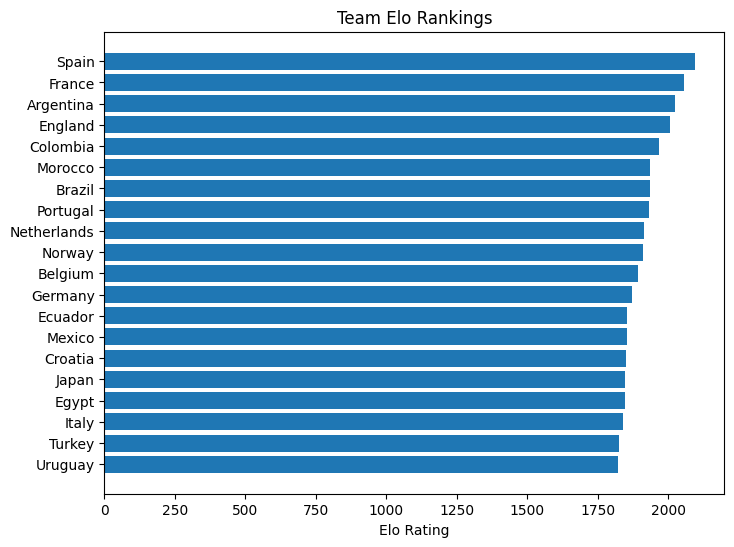

In [18]:
top20 = elos_df.sort_values("elo", ascending=False).head(20)
plt.figure(figsize=(8,6))
plt.barh(top20["team"], top20["elo"])
plt.gca().invert_yaxis()
plt.xlabel("Elo Rating")
plt.title("Team Elo Rankings")
plt.show()

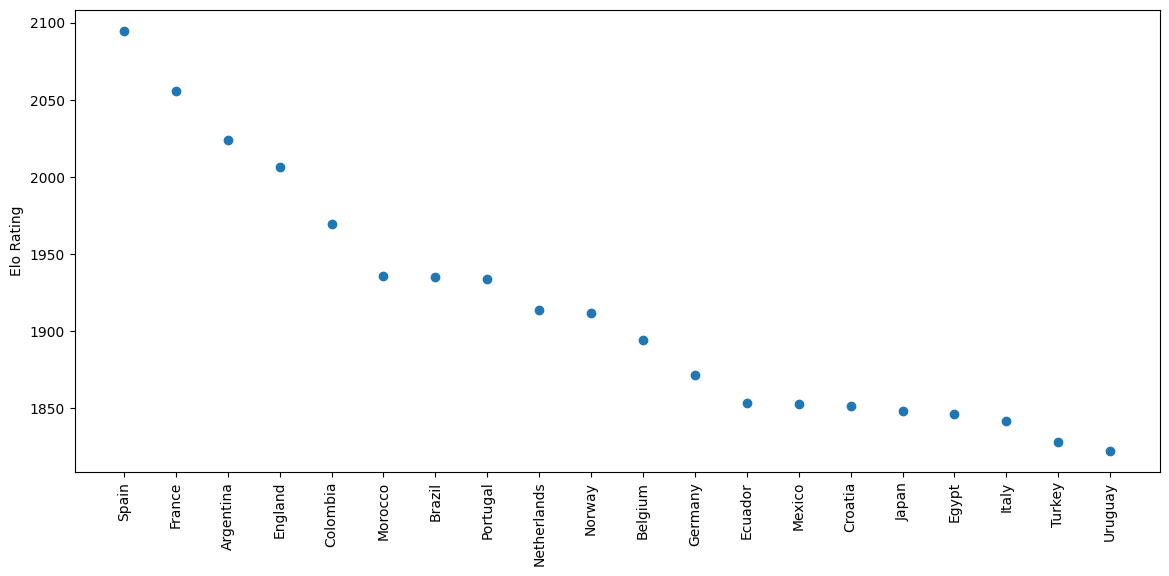

In [19]:
plt.figure(figsize=(14,6))
plt.scatter(top20["team"], top20["elo"])
plt.xticks(rotation=90)
plt.ylabel("Elo Rating")
plt.show()

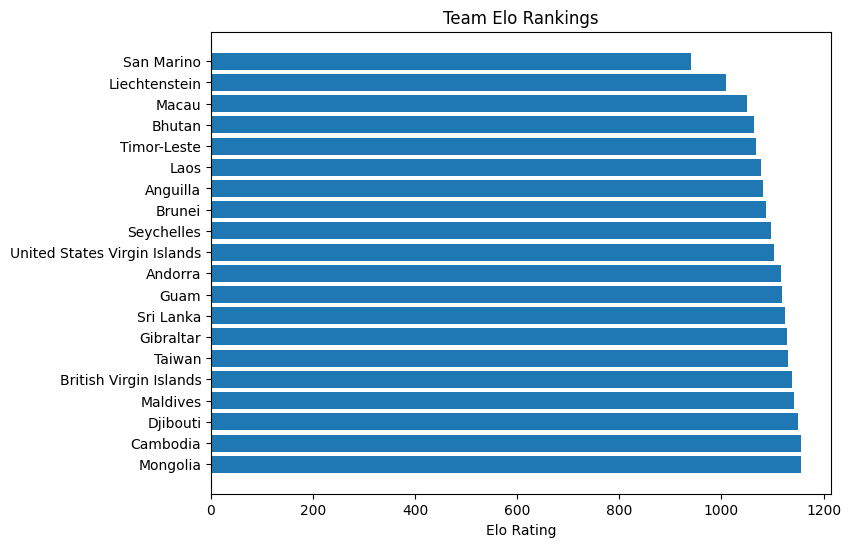

In [20]:
bot20 = elos_df.sort_values("elo", ascending=True).head(20)
plt.figure(figsize=(8,6))
plt.barh(bot20["team"], bot20["elo"])
plt.gca().invert_yaxis()
plt.xlabel("Elo Rating")
plt.title("Team Elo Rankings")
plt.show()

In [21]:
results_df.head(5)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_elo,away_elo
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,1500.000000,1500.000000
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,1501.400650,1498.599350
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,1495.037066,1504.962934
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,1501.230923,1498.769077
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,1500.202310,1499.797690


In [22]:
all_ts = list(results_df["tournament"].unique())

In [23]:
# with open("tournamens.txt","w") as f:
#     for line in all_ts:
#         f.write(line)
#         f.write("\n")

In [24]:
results_df["elo_diff"] = results_df["home_elo"] - results_df["away_elo"]

In [25]:
results_df["elo_diff"] = results_df["home_elo"] - results_df["away_elo"]


results_df['match_id'] = results_df.index

home_long = results_df[['match_id','date','home_team','home_score']].rename(columns={'home_team':'team','home_score':'goals_for'})
home_long['role'] = 'home'
print(home_long.head(5))

away_long = results_df[['match_id','date','away_team','away_score']].rename(columns={'away_team':'team','away_score':'goals_for'})
away_long['role'] = 'away'
print(away_long.head(5))

long_df = pd.concat([home_long, away_long]).sort_values('date').reset_index(drop=True)

long_df['rolling_mean_3'] = long_df.groupby('team')['goals_for'].transform(lambda x: x.shift(1).rolling(3).mean())
long_df['rolling_mean_5'] = long_df.groupby('team')['goals_for'].transform(lambda x: x.shift(1).rolling(5).mean())
long_df['rolling_mean_10'] = long_df.groupby('team')['goals_for'].transform(lambda x: x.shift(1).rolling(10).mean())

long_df["rolling_sum_3"] = long_df.groupby("team")["goals_for"].transform(lambda x: x.shift(1).rolling(3).sum())
long_df["rolling_sum_5"] = long_df.groupby("team")["goals_for"].transform(lambda x: x.shift(1).rolling(5).sum())
long_df["rolling_sum_10"] = long_df.groupby("team")["goals_for"].transform(lambda x: x.shift(1).rolling(10).sum())

long_df.head(5)

   match_id        date      team  goals_for  role
0         0  1872-11-30  Scotland        0.0  home
1         1  1873-03-08   England        4.0  home
2         2  1874-03-07  Scotland        2.0  home
3         3  1875-03-06   England        2.0  home
4         4  1876-03-04  Scotland        3.0  home
   match_id        date      team  goals_for  role
0         0  1872-11-30   England        0.0  away
1         1  1873-03-08  Scotland        2.0  away
2         2  1874-03-07   England        1.0  away
3         3  1875-03-06  Scotland        2.0  away
4         4  1876-03-04   England        0.0  away


,match_id,date,team,goals_for,role,rolling_mean_3,rolling_mean_5,rolling_mean_10,rolling_sum_3,rolling_sum_5,rolling_sum_10
0,0,1872-11-30,Scotland,0.0,home,NaN,NaN,NaN,NaN,NaN,NaN
1,0,1872-11-30,England,0.0,away,NaN,NaN,NaN,NaN,NaN,NaN
2,1,1873-03-08,England,4.0,home,NaN,NaN,NaN,NaN,NaN,NaN
3,1,1873-03-08,Scotland,2.0,away,NaN,NaN,NaN,NaN,NaN,NaN
4,2,1874-03-07,Scotland,2.0,home,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
home_rolling = long_df[long_df['role']=='home'][['match_id','rolling_mean_3','rolling_mean_5','rolling_mean_10','rolling_sum_3','rolling_sum_5','rolling_sum_10']].rename(
    columns={
        'rolling_mean_3':'home_rolling_mean_3','rolling_mean_5':'home_rolling_mean_5','rolling_mean_10':'home_rolling_mean_10',
        'rolling_sum_3':'home_rolling_sum_3','rolling_sum_5':'home_rolling_sum_5','rolling_sum_10':'home_rolling_sum_10',  
            })

away_rolling = long_df[long_df['role']=='away'][['match_id','rolling_mean_3','rolling_mean_5','rolling_mean_10','rolling_sum_3','rolling_sum_5','rolling_sum_10']].rename(
    columns={
        'rolling_mean_3':'away_rolling_mean_3','rolling_mean_5':'away_rolling_mean_5','rolling_mean_10':'away_rolling_mean_10',
        'rolling_sum_3':'away_rolling_sum_3','rolling_sum_5':'away_rolling_sum_5','rolling_sum_10':'away_rolling_sum_10',
            })

results_df = results_df.merge(home_rolling, on='match_id').merge(away_rolling, on='match_id')

In [27]:
results_df[(results_df['home_team']=='Italy') & (results_df['away_team']=='France') & (results_df['date']=='2006-07-09')]

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_elo,...,home_rolling_mean_10,home_rolling_sum_3,home_rolling_sum_5,home_rolling_sum_10,away_rolling_mean_3,away_rolling_mean_5,away_rolling_mean_10,away_rolling_sum_3,away_rolling_sum_5,away_rolling_sum_10
30111,2006-07-09,Italy,France,1.0,1.0,FIFA World Cup,Berlin,Germany,True,1942.553044,...,1.7,6.0,9.0,17.0,1.666667,1.6,1.5,5.0,8.0,15.0


In [28]:
results_df.shape

(49501, 25)

In [29]:
results_df.isna().sum()

date                       0
home_team                  0
away_team                  0
home_score                 6
away_score                 6
tournament                 0
city                       0
country                    0
neutral                    0
home_elo                   0
away_elo                   0
elo_diff                   0
match_id                   0
home_rolling_mean_3      437
home_rolling_mean_5      757
home_rolling_mean_10    1448
home_rolling_sum_3       437
home_rolling_sum_5       757
home_rolling_sum_10     1448
away_rolling_mean_3      545
away_rolling_mean_5      838
away_rolling_mean_10    1600
away_rolling_sum_3       545
away_rolling_sum_5       838
away_rolling_sum_10     1600
dtype: int64

In [32]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
elo_cols = ["home_elo","away_elo"]

ml_df = results_df.copy()

ml_df["neutral"] = ml_df["neutral"].astype(int)

In [33]:
train_df = ml_df[ml_df['date'] < '2026-06-28']
predict_df = ml_df[ml_df['date'] >= '2026-06-28']

train_df = train_df.dropna()

In [34]:
ml_features = ["neutral",'home_elo', 'away_elo',
       'elo_diff', 'home_rolling_mean_3', 'home_rolling_mean_5',
       'home_rolling_mean_10', 'home_rolling_sum_3', 'home_rolling_sum_5',
       'home_rolling_sum_10', 'away_rolling_mean_3', 'away_rolling_mean_5',
       'away_rolling_mean_10', 'away_rolling_sum_3', 'away_rolling_sum_5',
       'away_rolling_sum_10']

In [35]:
scaling_cols = ['home_elo', 'away_elo',
       'elo_diff', 'home_rolling_mean_3', 'home_rolling_mean_5',
       'home_rolling_mean_10', 'home_rolling_sum_3', 'home_rolling_sum_5',
       'home_rolling_sum_10', 'away_rolling_mean_3', 'away_rolling_mean_5',
       'away_rolling_mean_10', 'away_rolling_sum_3', 'away_rolling_sum_5',
       'away_rolling_sum_10']

scalers = {}
for i in scaling_cols:
    scalers[i] = StandardScaler()
    train_df[i] = scalers[i].fit_transform(train_df[[i]])

In [36]:
from sklearn.linear_model import PoissonRegressor

X_train = train_df[ml_features]
y_train_home = train_df["home_score"]
y_train_away = train_df["away_score"]

home_model = PoissonRegressor()
home_model.fit(X_train, y_train_home)

away_model = PoissonRegressor()
away_model.fit(X_train, y_train_away)

,"alpha alpha: float, default=1Constant that multiplies the L2 penalty term and determines theregularization strength. ``alpha = 0`` is equivalent to unpenalizedGLMs. In this case, the design matrix `X` must have full column rank(no collinearities).Values of `alpha` must be in the range `[0.0, inf)`.",1.0
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the linear predictor (`X @ coef + intercept`).",True
,"solver solver: {'lbfgs', 'newton-cholesky'}, default='lbfgs'Algorithm to use in the optimization problem:'lbfgs' Calls scipy's L-BFGS-B optimizer.'newton-cholesky' Uses Newton-Raphson steps (in arbitrary precision arithmetic equivalent to iterated reweighted least squares) with an inner Cholesky based solver. This solver is a good choice for `n_samples` >> `n_features`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features` because it explicitly computes the Hessian matrix. .. versionadded:: 1.2",'lbfgs'
,"max_iter max_iter: int, default=100The maximal number of iterations for the solver.Values must be in the range `[1, inf)`.",100
,"tol tol: float, default=1e-4Stopping criterion. For the lbfgs solver,the iteration will stop when ``max{|g_j|, j = 1, ..., d} <= tol``where ``g_j`` is the j-th component of the gradient (derivative) ofthe objective function.Values must be in the range `(0.0, inf)`.",0.0001
,"warm_start warm_start: bool, default=FalseIf set to ``True``, reuse the solution of the previous call to ``fit``as initialization for ``coef_`` and ``intercept_`` .",False
,"verbose verbose: int, default=0For the lbfgs solver set verbose to any positive number for verbosity.Values must be in the range `[0, inf)`.",0


In [37]:
predict_df[ml_features].isna().sum()

neutral                 0
home_elo                0
away_elo                0
elo_diff                0
home_rolling_mean_3     0
home_rolling_mean_5     0
home_rolling_mean_10    0
home_rolling_sum_3      0
home_rolling_sum_5      0
home_rolling_sum_10     0
away_rolling_mean_3     0
away_rolling_mean_5     0
away_rolling_mean_10    0
away_rolling_sum_3      0
away_rolling_sum_5      0
away_rolling_sum_10     0
dtype: int64

In [38]:
predict_df

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_elo,...,home_rolling_mean_10,home_rolling_sum_3,home_rolling_sum_5,home_rolling_sum_10,away_rolling_mean_3,away_rolling_mean_5,away_rolling_mean_10,away_rolling_sum_3,away_rolling_sum_5,away_rolling_sum_10
49477,2026-06-28,Canada,South Africa,1.0,0.0,FIFA World Cup,California,United States,1,1806.608607,...,1.6,9.0,12.0,16.0,0.666667,0.6,0.9,2.0,3.0,9.0
49478,2026-06-29,Brazil,Japan,2.0,1.0,FIFA World Cup,Texas,United States,1,1949.656891,...,2.4,7.0,15.0,24.0,2.333333,1.8,2.0,7.0,9.0,20.0
49479,2026-06-29,Germany,Paraguay,1.0,1.0,FIFA World Cup,Boston,United States,1,1876.169543,...,3.1,10.0,16.0,31.0,0.666667,1.4,1.3,2.0,7.0,13.0
49480,2026-06-30,Netherlands,Morocco,1.0,1.0,FIFA World Cup,Mexico City,Mexico,1,1913.564826,...,2.4,10.0,12.0,24.0,2.000000,2.2,2.2,6.0,11.0,22.0
49481,2026-06-30,Ivory Coast,Norway,1.0,2.0,FIFA World Cup,Texas,United States,1,1777.492845,...,2.0,4.0,7.0,20.0,2.666667,2.4,2.2,8.0,12.0,22.0
49482,2026-06-30,France,Sweden,3.0,0.0,FIFA World Cup,New Jersey,United States,1,2034.137908,...,2.8,10.0,14.0,28.0,2.333333,2.0,1.8,7.0,10.0,18.0
49483,2026-07-01,Mexico,Ecuador,2.0,0.0,FIFA World Cup,Mexico City,Mexico,0,1860.482531,...,1.7,3.0,9.0,17.0,0.666667,1.4,1.2,2.0,7.0,12.0
49484,2026-07-01,England,DR Congo,2.0,1.0,FIFA World Cup,Atlanta,United States,1,1962.679636,...,2.0,6.0,10.0,20.0,1.333333,1.0,1.2,4.0,5.0,12.0
49485,2026-07-01,Belgium,Senegal,3.0,2.0,FIFA World Cup,Seattle,United States,1,1833.558173,...,3.1,6.0,13.0,31.0,2.666667,2.0,1.7,8.0,10.0,17.0
49486,2026-07-02,United States,Bosnia and Herzegovina,2.0,0.0,FIFA World Cup,Santa Clara,United States,0,1763.540700,...,2.3,8.0,12.0,23.0,1.666667,1.2,1.6,5.0,6.0,16.0


In [39]:
for i in scaling_cols:
    predict_df[i] = scalers[i].transform(predict_df[[i]])

In [40]:
X_predict = predict_df[ml_features]
pred_home = home_model.predict(X_predict)
pred_away = away_model.predict(X_predict)

In [41]:
predict_df["pred_home"] = pred_home
predict_df["pred_away"] = pred_away
predict_df[["home_team","away_team","pred_home","pred_away","home_score","away_score"]]

,home_team,away_team,pred_home,pred_away,home_score,away_score
49477,Canada,South Africa,1.926248,0.756605,1.0,0.0
49478,Brazil,Japan,1.702813,0.991819,2.0,1.0
49479,Germany,Paraguay,1.996572,0.859906,1.0,1.0
49480,Netherlands,Morocco,1.549159,1.115030,1.0,1.0
49481,Ivory Coast,Norway,1.263747,1.373446,1.0,2.0
49482,France,Sweden,2.630478,0.709731,3.0,0.0
49483,Mexico,Ecuador,1.383152,0.941148,2.0,0.0
49484,England,DR Congo,2.023633,0.719847,2.0,1.0
49485,Belgium,Senegal,1.709550,1.099422,3.0,2.0
49486,United States,Bosnia and Herzegovina,2.125151,0.861284,2.0,0.0


In [42]:
get_latest = pd.read_csv("football_results/results_v003.csv",encoding="utf-8")